# Rayleigh numbers

## Run the simulations

In [ ]:
import numpy as np
from functools import partial
from lucifex.sim import parallel_run, as_grid_simulation
from lucifex.plt import plot_colormap, plot_line, set_ipynb_variable
from lucifex.utils.npy_utils import as_index
from crocodil.theory.system_a import threshold_rayleigh
from crocodil.dns.system_a import dns_system_a, SYSTEM_A_REFERENCE

STORE = 1
create_sim = dns_system_a(store_delta=STORE)

NX = set_ipynb_variable('NX', 80)
NY = set_ipynb_variable('NY', 80)
COURANT_ADV = 0.75
COURANT_DIFF = 0.75
COURANT_REAC = 0.1
Ra_ref = SYSTEM_A_REFERENCE['Ra']
Ra_opts = tuple(i * Ra_ref for i in (0.5, 1.0, 1.5))

Ra_thresh = threshold_rayleigh(SYSTEM_A_REFERENCE['aspect'], 1.0, NX, 2)
print(f"Ra_max = {max(Ra_opts)} , Ra_thresh = {Ra_thresh}")

n_proc = set_ipynb_variable('N_PROC', 3)
n_stop = set_ipynb_variable('N_STOP', 600)
t_stop = 20.0
dt_init = 1e-6
n_init = 10

simulations = parallel_run(
    create_sim, n_proc, n_stop,
    dt_init=dt_init, n_init=n_init,
    serialize=partial(as_grid_simulation, include=('c', 's', 'mC', 'mD', 'f')),
)(
    cell='quadrilateral',
    scaling='advective',
    **{k: v for k, v in SYSTEM_A_REFERENCE.items() if k != 'Ra'},
    dt_Cu=COURANT_ADV,
    dt_Cd=COURANT_DIFF,
    dt_Cr=COURANT_REAC,
    c_stabilization=None,
    c_limits=True,
    diagnostic=True,
)(
    Ra=Ra_opts,
)

Ra_max = 1500.0 , Ra_thresh = 1800.0


## Lines

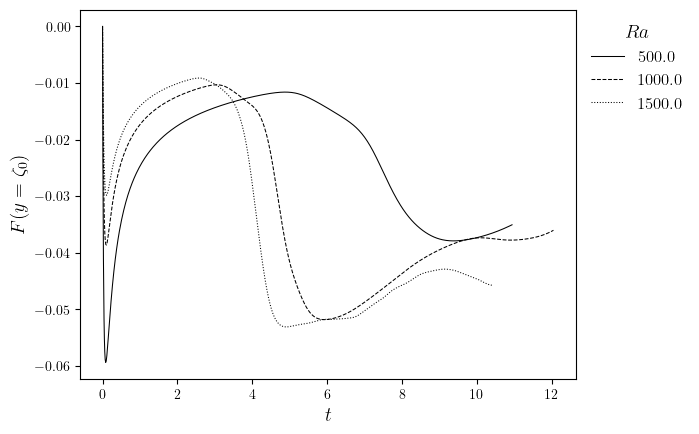

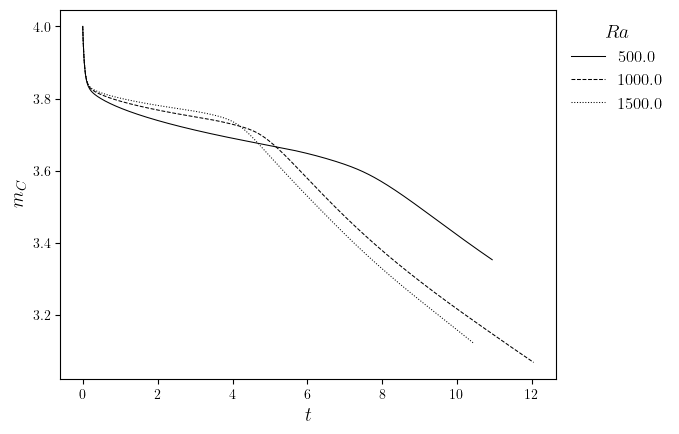

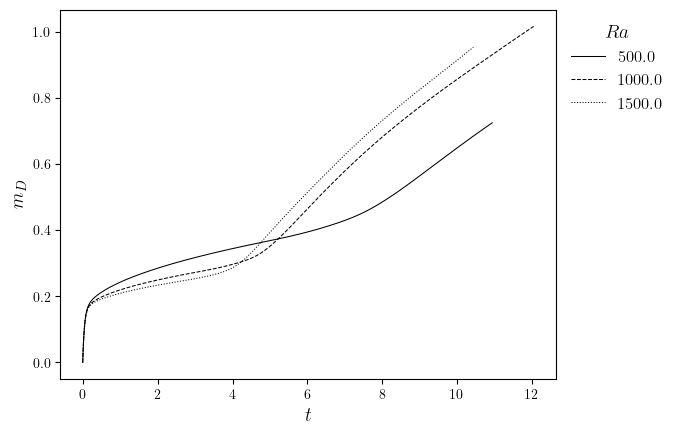

In [10]:
f_lines, mC_lines, mD_lines = [], [], []
for Ra, sim in simulations.items():
    sim = simulations[Ra]
    f, mC, mD = sim['f', 'mC', 'mD']
    fZeta0, fZetaPlus, fZetaMinus = f.split()
    f_lines.append((fZeta0.time_series, [np.sum(i) for i in fZeta0.value_series]))
    mC_lines.append((mC.time_series, mC.value_series))
    mD_lines.append((mD.time_series, mD.value_series))

line_kws = dict(
    cyc='black',
    x_label='$t$',
    legend_labels=list(Ra_opts),
    legend_title='$Ra$',
)

fig, ax = plot_line(f_lines, y_label='$F(y=\zeta_0)$', **line_kws)

fig, ax = plot_line(mC_lines, y_label='$m_C$', **line_kws)

fig, ax = plot_line(mD_lines, y_label='$m_D$', **line_kws)

## Colormaps

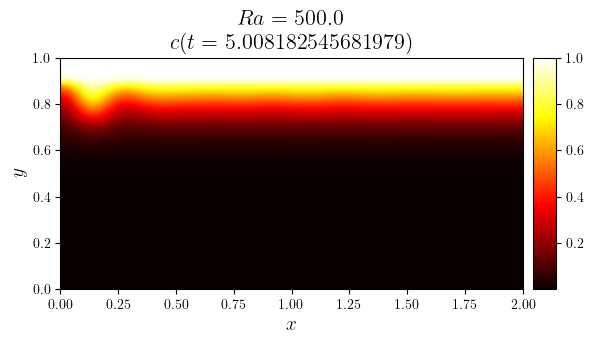

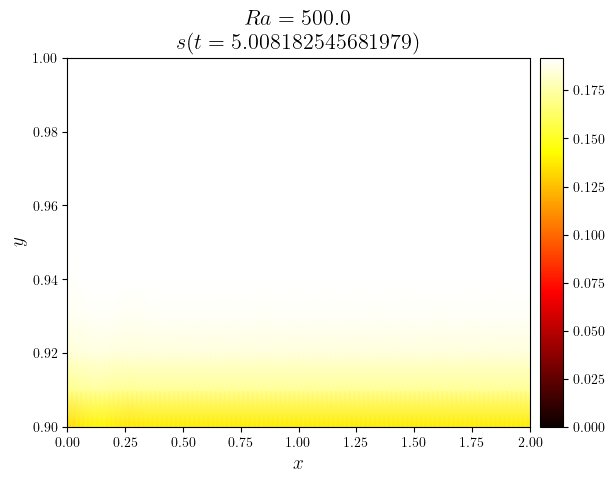

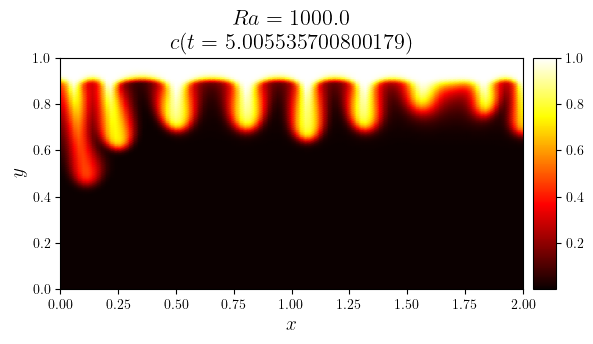

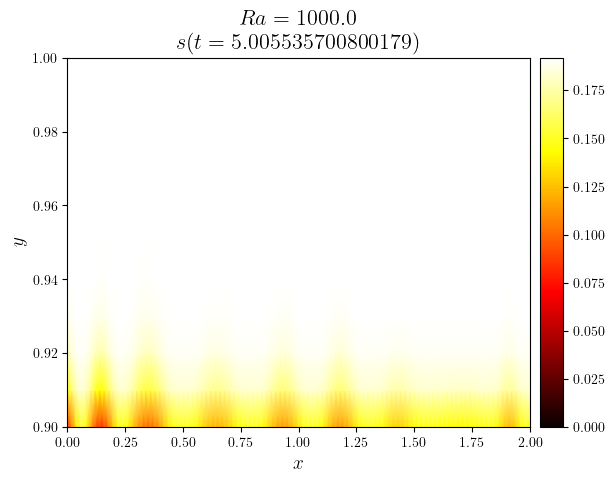

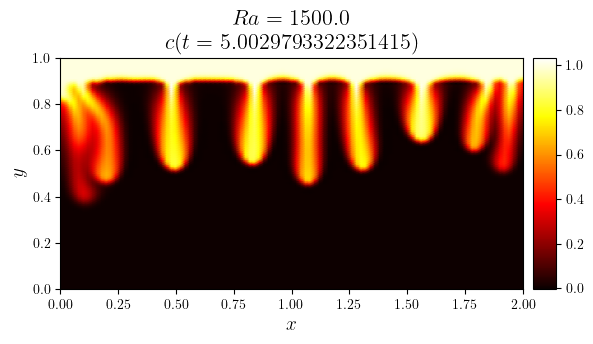

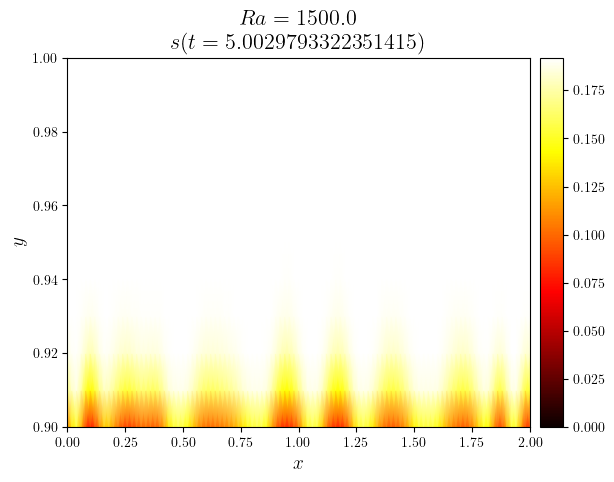

In [9]:
c_t_target = 5.0
s_t_target = 5.0

for Ra, sim in simulations.items():
    c = sim['c']
    time_index = as_index(c.time_series, c_t_target)
    fig, ax = plot_colormap(
        c.series[time_index], 
        title=f'$Ra={Ra}$\n$c(t={c.time_series[time_index]})$',
    )
    s = sim['s']
    zeta0, Lx, Ly = (float(i) for i in sim['zeta0', 'Lx', 'Ly'])
    time_index = as_index(s.time_series, s_t_target)
    fig, ax = plot_colormap(
        s.series[time_index], 
        title=f'$Ra={Ra}$\n$s(t={s.time_series[time_index]})$',
        y_lims=(zeta0 * Ly, Ly),
        aspect='auto',
    )
    